In [1]:
#Task3: Gaussian Mixture Model
#Step1: Step 1: Create Two Clusters
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# Cluster 1
mean1 = [4.5, 1.8]
cov1 = [[0.2, 0.05],
        [0.05, 0.1]]

data1 = np.random.multivariate_normal(mean1, cov1, 100)

# Cluster 2
mean2 = [6.0, 2.5]
cov2 = [[0.3, -0.04],
        [-0.04, 0.2]]

data2 = np.random.multivariate_normal(mean2, cov2, 100)

# Combine
X = np.vstack((data1, data2))


In [2]:
#means → centers of clusters (high usage / low usage houses)

#covariances → spread of clusters

#weights → probability of each cluster
# We start with random guesses.


k = 2  # number of clusters

n, d = X.shape  # n samples, d features

# Initial means
means = X[np.random.choice(n, k, replace=False)]

# Initial covariance matrices
covariances = [np.cov(X.T) for _ in range(k)]

# Initial mixing coefficients
weights = np.ones(k) / k



Iteration 40
Weights (pi):
[0.41231365 0.58768635]
Means (mu):
[[6.08280982 2.57293079]
 [4.65284951 1.91377938]]
Covariances (sigma):
Sigma 1:
[[ 0.23818785 -0.07741356]
 [-0.07741356  0.18498753]]
Sigma 2:
[[0.22210583 0.07601603]
 [0.07601603 0.1241677 ]]


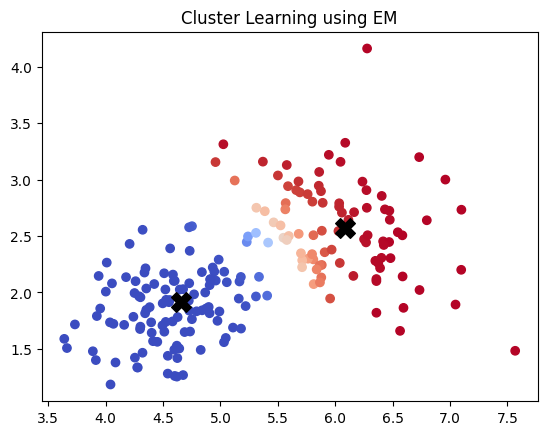

In [3]:
iterations = 40

for step in range(iterations):

    # E-step
    responsibilities = np.zeros((n, k))
    for i in range(k):
        rv = multivariate_normal(means[i], covariances[i])
        responsibilities[:, i] = weights[i] * rv.pdf(X)
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    # M-step
    Nk = responsibilities.sum(axis=0)
    weights = Nk / n
    means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

    covariances = []
    for i in range(k):
        diff = X - means[i]
        cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
        covariances.append(cov)
            
print(f"\nIteration {step+1}")
print("Weights (pi):")
print(weights)
print("Means (mu):")
print(means)
print("Covariances (sigma):")
for i in range(k):
    print(f"Sigma {i+1}:")
    print(covariances[i])

plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
plt.title("Cluster Learning using EM")
plt.show()

In [4]:
'''
iterations = [2,10,17,25,33,40]
for iteration in iterations:

    for step in range(iteration):

        # E-step
        responsibilities = np.zeros((n, k))
        for i in range(k):
            rv = multivariate_normal(means[i], covariances[i])
            responsibilities[:, i] = weights[i] * rv.pdf(X)
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n
        means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

        covariances = []
        for i in range(k):
            diff = X - means[i]
            cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
            covariances.append(cov)
            
    print(f"\nIteration {step+1}")
    print("Weights (pi):")
    print(weights)
    print("Means (mu):")
    print(means)
    print("Covariances (sigma):")
    for i in range(k):
        print(f"Sigma {i+1}:")
        print(covariances[i])

    plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
    plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
    plt.title("Cluster Learning using EM")
    plt.show()
'''

'\niterations = [2,10,17,25,33,40]\nfor iteration in iterations:\n\n    for step in range(iteration):\n\n        # E-step\n        responsibilities = np.zeros((n, k))\n        for i in range(k):\n            rv = multivariate_normal(means[i], covariances[i])\n            responsibilities[:, i] = weights[i] * rv.pdf(X)\n        responsibilities /= responsibilities.sum(axis=1, keepdims=True)\n\n        # M-step\n        Nk = responsibilities.sum(axis=0)\n        weights = Nk / n\n        means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]\n\n        covariances = []\n        for i in range(k):\n            diff = X - means[i]\n            cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]\n            covariances.append(cov)\n\n    print(f"\nIteration {step+1}")\n    print("Weights (pi):")\n    print(weights)\n    print("Means (mu):")\n    print(means)\n    print("Covariances (sigma):")\n    for i in range(k):\n        print(f"Sigma {i+1}:")\n        print(covariances[i])\